# Attention & Softmax — How Models Decide What to Focus On

In [ ]:
# If you are running this on Google Colab, uncomment and run the line below first.
# !pip install -q torch numpy matplotlib

## The problem attention is solving

By now you know that text becomes tokens, and tokens become embeddings — vectors that carry meaning.

But here is the thing. A word does not have just one fixed meaning. The word **"bank"** means something completely different in these two sentences:

- *"I went to the bank to deposit money."*
- *"The kids played on the river bank."*

The embedding for "bank" is just one vector. How does the model know which meaning applies in each sentence?

The answer is **attention**. Instead of giving every word a fixed meaning, attention lets each word look at all the other words around it and adjust its meaning based on context.

Think of it like this — imagine you are at a loud party and someone says *"I need to get to the bank before it closes."* You automatically tune out the music and focus on the words *"before it closes"* to figure out they mean a financial institution, not a riverbank. You are doing attention. You are deciding which parts of the input to pay more attention to.

## Softmax — turning scores into probabilities

Before we get into attention properly, we need to understand **softmax**, because attention uses it constantly.

Softmax takes a list of raw numbers and converts them into probabilities that sum to 1. That is its entire job.

**A real world analogy:** Imagine you are deciding where to have lunch. You score three options:
- Biryani place: 8
- Burger joint: 3
- Salad bar: 1

Softmax does not just pick the highest score. It converts all three scores into a percentage share — so instead of raw numbers, you get something like 95%, 4%, 1%. The highest scorer dominates, but the others still get a small weight. Nothing is completely ignored.

This matters in attention because the model needs to assign a "how much do I care about this word" weight to every single word in the sentence — and those weights need to sum to 1 so they can be used to take a weighted average.

In [1]:
import numpy as np

def softmax(scores):
    # Subtract the max for numerical stability — same result, avoids overflow
    shifted = scores - np.max(scores)
    exp_scores = np.exp(shifted)
    return exp_scores / exp_scores.sum()

# Lunch scores
scores = np.array([8.0, 3.0, 1.0])
probs  = softmax(scores)

options = ["Biryani place", "Burger joint", "Salad bar"]
print("Lunch decision via Softmax\n")
print(f"{'Option':<18}  {'Raw Score':>10}  {'Probability':>12}")
print("-" * 45)
for option, score, prob in zip(options, scores, probs):
    print(f"{option:<18}  {score:>10.1f}  {prob:>11.1%}")

print(f"\nAll probabilities sum to: {probs.sum():.4f}")
print("\nThe highest score dominates, but everything gets a weight.")
print("Nothing is completely zeroed out — the model always considers all options.")

Lunch decision via Softmax

Option               Raw Score   Probability
---------------------------------------------
Biryani place              8.0        99.2%
Burger joint               3.0         0.7%
Salad bar                  1.0         0.1%

All probabilities sum to: 1.0000

The highest score dominates, but everything gets a weight.
Nothing is completely zeroed out — the model always considers all options.


## How attention actually works — the classroom analogy

Here is the clearest way to think about attention.

Imagine a classroom. A student asks the teacher a question. The teacher does not treat every student in the room equally when forming their answer — they focus more on students who have relevant context (the ones who worked on the same problem), and less on students who are talking about something unrelated.

In attention:
- The **query** is the student asking the question — the word currently trying to understand its context
- The **keys** are name tags on every other student — a summary of what each word is about
- The **values** are what each student actually knows — the content each word carries

The process is:
1. Compare the query against every key to get a score — "how relevant is this word to me?"
2. Run those scores through softmax to get weights that sum to 1
3. Take a weighted sum of all the values using those weights — "blend together the most relevant information"

The result is a new, context-aware representation of the word. The same word "bank" will produce a different output vector depending on whether the surrounding words are about money or rivers.

In [3]:
import numpy as np

np.random.seed(42)

def softmax(x):
    x = x - np.max(x)
    return np.exp(x) / np.exp(x).sum()

# Tiny example: 4 words, each represented by a 4-dimensional embedding
words = ["The", "river", "bank", "flooded"]
d     = 4   # embedding dimension

# In a real transformer, Q/K/V weight matrices are learned during training.
# Here we use small random values just to see the mechanics.
np.random.seed(7)
W_q = np.random.randn(d, d) * 0.5
W_k = np.random.randn(d, d) * 0.5
W_v = np.random.randn(d, d) * 0.5

# Fake embeddings for each word
X = np.random.randn(len(words), d)

Q = X @ W_q   # Queries — what each word is asking
K = X @ W_k   # Keys    — what each word is advertising
V = X @ W_v   # Values  — what each word will contribute

# Step 1: compute raw attention scores (dot product of Q and K)
scores = Q @ K.T / np.sqrt(d)   # scale by sqrt(d) to prevent large values

# Step 2: softmax to get attention weights
weights = np.array([softmax(scores[i]) for i in range(len(words))])

# Step 3: weighted sum of values
output = weights @ V

print("Attention weights for each word (rows = query word, cols = key word)\n")
print(f"{'':>10}", end="")
for w in words:
    print(f"{w:>10}", end="")
print()
print("-" * 50)
for i, word in enumerate(words):
    print(f"{word:>10}", end="")
    for j in range(len(words)):
        print(f"{weights[i][j]:>10.3f}", end="")
    print()

print()
print("Each row sums to 1.0 — these are the attention weights.")
print("Higher weight = the query word is paying more attention to that key word.")

Attention weights for each word (rows = query word, cols = key word)

                 The     river      bank   flooded
--------------------------------------------------
       The     0.112     0.244     0.526     0.118
     river     0.245     0.251     0.242     0.262
      bank     0.740     0.063     0.008     0.189
   flooded     0.136     0.229     0.483     0.152

Each row sums to 1.0 — these are the attention weights.
Higher weight = the query word is paying more attention to that key word.


## Scaled dot-product attention — why we divide by √d

You might have noticed we divided the scores by `√d` (square root of the embedding dimension) in the code above. This is called **scaling**, and it is a small but important detail.

Here is why it matters. The dot product of two vectors grows larger as the vectors get longer (higher dimensions). Without scaling, the scores become very large numbers. When you put very large numbers through softmax, one score dominates so strongly that everything else gets a weight near zero — the model effectively ignores all other words.

Dividing by √d keeps the scores in a reasonable range so that softmax can produce meaningful, spread-out weights.

Think of it like volume on a speaker. Without scaling, the loudest voice in the room completely drowns everyone else out. Dividing by √d turns the volume down to a level where everyone can be heard.

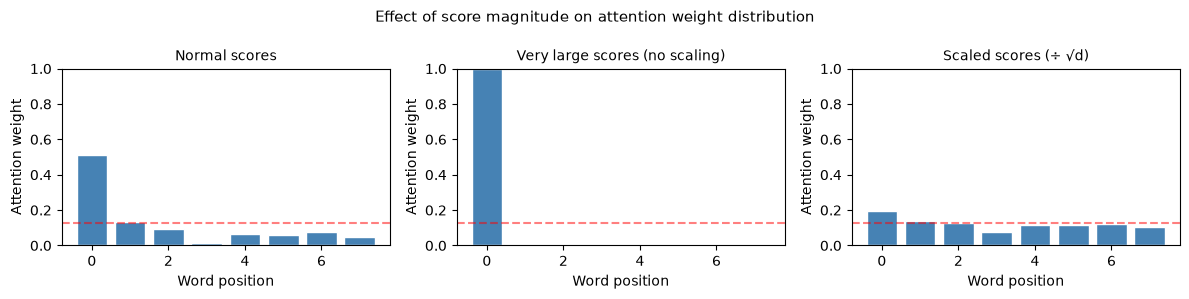

Middle plot: one word gets almost all the attention — the model ignores the rest.
Right plot : scaling spreads the attention more evenly across relevant words.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    x = x - np.max(x)
    return np.exp(x) / np.exp(x).sum()

# Show what happens to softmax output as scores get bigger
np.random.seed(3)
base_scores = np.random.randn(8)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
scales = [1, 10, 0.25]
titles = ["Normal scores", "Very large scores (no scaling)", "Scaled scores (÷ √d)"]

for ax, scale, title in zip(axes, scales, titles):
    scores = base_scores * scale
    weights = softmax(scores)
    ax.bar(range(len(weights)), weights, color="steelblue", edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Word position")
    ax.set_ylabel("Attention weight")
    ax.set_ylim(0, 1)
    ax.axhline(1/len(weights), color="red", linestyle="--", alpha=0.5, label="Uniform")

plt.suptitle("Effect of score magnitude on attention weight distribution", fontsize=11)
plt.tight_layout()
plt.show()

print("Middle plot: one word gets almost all the attention — the model ignores the rest.")
print("Right plot : scaling spreads the attention more evenly across relevant words.")

## Putting it together — what attention produces

Let's use a concrete sentence and trace exactly what attention does, step by step, in plain English.

Sentence: **"The trophy didn't fit in the bag because it was too big."**

What does "it" refer to — the trophy or the bag?

You know it is the trophy, because "too big" makes more sense for something that does not fit. But how? You looked at the surrounding words and used context. Attention does the same thing.

When the model processes the word "it", attention assigns high weights to "trophy" and "big" and "fit" — the words most relevant to resolving what "it" refers to. The output for "it" is then a blend of those contextually important words, and the model's representation of "it" in this sentence ends up much closer to "trophy" than to "bag".

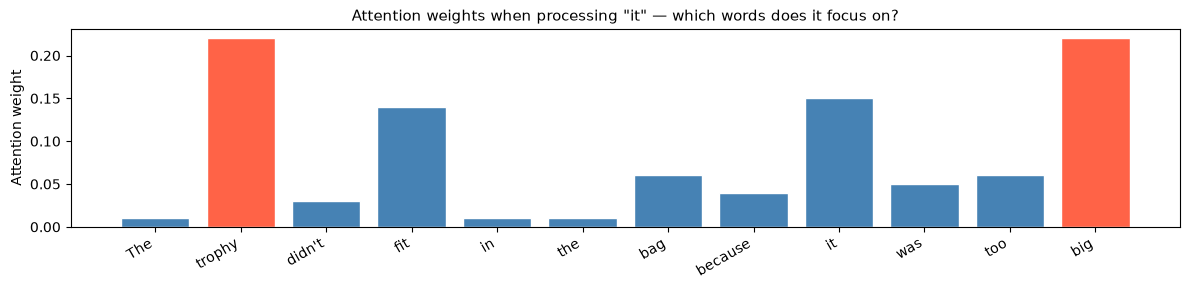

The model learns to attend heavily to 'trophy' and 'big' when resolving 'it'.
This is how attention solves ambiguous references — by looking at surrounding context.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    x = x - np.max(x)
    return np.exp(x) / np.exp(x).sum()

# Manually craft plausible attention weights for the word "it"
# to illustrate what a trained model might learn
words = ["The", "trophy", "didn't", "fit", "in", "the", "bag", "because", "it", "was", "too", "big"]

# Imagined attention weights when the model processes "it"
# High on trophy, fit, big — low on stopwords
attention_on_it = np.array([0.01, 0.22, 0.03, 0.14, 0.01, 0.01, 0.06, 0.04, 0.15, 0.05, 0.06, 0.22])
attention_on_it = attention_on_it / attention_on_it.sum()  # ensure sums to 1

plt.figure(figsize=(12, 3))
colors = ["tomato" if w in ["trophy", "big"] else "steelblue" for w in words]
plt.bar(words, attention_on_it, color=colors, edgecolor="white")
plt.title('Attention weights when processing "it" — which words does it focus on?', fontsize=11)
plt.ylabel("Attention weight")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("The model learns to attend heavily to 'trophy' and 'big' when resolving 'it'.")
print("This is how attention solves ambiguous references — by looking at surrounding context.")

## Key takeaways

- **Attention** lets each word look at all other words in the sentence and decide how much to focus on each one. This is how the model handles context and ambiguity.
- **Query, Key, Value** are the three ingredients: the word asking a question (Q), the labels on all words (K), and the content each word carries (V).
- **Softmax** converts raw scores into probabilities that sum to 1 — giving every word a weight that represents how much attention to pay it.
- **Scaling by √d** prevents softmax from becoming winner-takes-all when scores are very large.
- The output of attention is a new, context-aware representation of each word — the same word gets a different output depending on the sentence it appears in.

---

Next up: **Transformer Internals** — attention is one piece. The full transformer stacks it with positional encodings, feed-forward layers, and normalization to build the architecture behind GPT, BERT, and LLaMA.